## Pra-pemrosesan Data & Exploratory Data Analysis (EDA)
### Studi Kasus: Prediksi Customer Churn Telekomunikasi

Inisialisasi Environment & Load Data

In [1]:
# Import core dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder

# Set aesthetics for plotting
sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
train_path = './Data/train.csv'
test_path = './Data/test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Train set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

Train set shape: (594194, 21)
Test set shape: (254655, 20)


# DATA TRAIN!

Inspeksi Data Awal & EDA (Masih pakai data Train)

In [ ]:
# Informasi Penting
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [6]:
# Statistika Deskriptif
df_train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [9]:
# Missing Values
missing_values = df_train.isnull().sum()
print(missing_values)

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
# 10 data teratas
df_train.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No



Target Class Distribution (%):
Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64


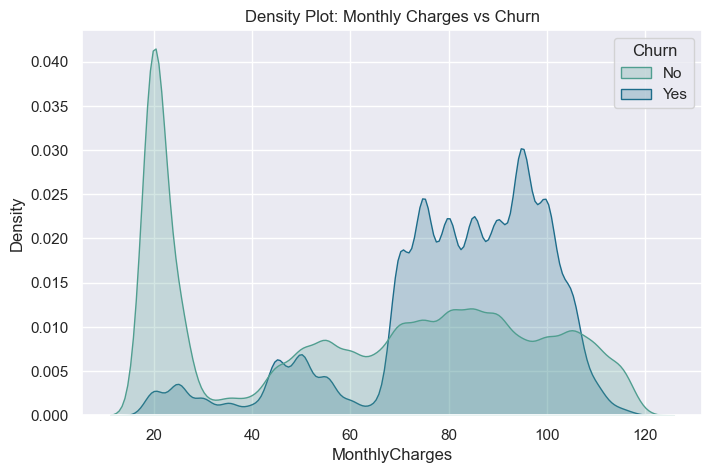

In [16]:
# Target Class Distribution
target_distribution = df_train['Churn'].value_counts(normalize=True)*100
print("\nTarget Class Distribution (%):")
print(target_distribution)

# Visualizing Numeric Features agains Target
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_train, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='crest') 
plt.title('Density Plot: Monthly Charges vs Churn') 
plt.show()